In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Verify mount
import os
print("✅ Drive mounted successfully!")
print("Current directory:", os.getcwd())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Drive mounted successfully!
Current directory: /content


In [ ]:
# Check GPU availability
import tensorflow as tf
print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))
print("Built with CUDA:", tf.test.is_built_with_cuda())

# If GPU is available, print GPU details
if tf.config.list_physical_devices('GPU'):
    gpu = tf.config.list_physical_devices('GPU')[0]
    print(f"✅ GPU detected: {gpu}")
    # Enable memory growth to prevent OOM errors
    tf.config.experimental.set_memory_growth(gpu, True)
else:
    print("⚠️ No GPU found! Check Runtime > Change runtime type > GPU")

TensorFlow version: 2.19.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Built with CUDA: True
✅ GPU detected: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import joblib
import gc
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# GPU optimization settings
tf.keras.mixed_precision.set_global_policy('mixed_float16')  # Use mixed precision for speed
print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


In [ ]:
# Define your Google Drive path to the CSV file
# Adjust this path based on where you uploaded tcga_filtered.csv
DRIVE_BASE = "/content/drive/MyDrive"

# Example paths - MODIFY THESE to match your folder structure:
DATA_PATH = f"{DRIVE_BASE}/tcga_filtered.csv"  # If file is in root of My Drive
# OR if in a subfolder:
# DATA_PATH = f"{DRIVE_BASE}/LeukemiaProject/data/tcga_filtered.csv"

# Create directories for outputs
MODEL_DIR = Path(f"{DRIVE_BASE}/models")
REPORTS_DIR = Path(f"{DRIVE_BASE}/reports/figures")
MODEL_DIR.mkdir(exist_ok=True, parents=True)
REPORTS_DIR.mkdir(exist_ok=True, parents=True)

print(f"📂 Data path: {DATA_PATH}")
print(f"📂 Models will be saved to: {MODEL_DIR}")
print(f"📂 Reports will be saved to: {REPORTS_DIR}")

# Verify file exists
if os.path.exists(DATA_PATH):
    print("✅ Data file found!")
else:
    print("❌ Data file NOT found! Please check the path.")

📂 Data path: /content/drive/MyDrive/tcga_filtered.csv
📂 Models will be saved to: /content/drive/MyDrive/models
📂 Reports will be saved to: /content/drive/MyDrive/reports/figures
✅ Data file found!


In [ ]:
def load_and_preprocess_data(data_path):
    """Memory-efficient data loading with GPU optimization"""
    print("🔹 Loading TCGA data for autoencoder training...")

    # Load data
    tcga_df = pd.read_csv(data_path, index_col=0)
    print(f"✅ TCGA data loaded: {tcga_df.shape}")

    # Convert to float32 (required for mixed precision)
    X_train = tcga_df.values.astype('float32')

    del tcga_df
    gc.collect()

    # Standardize data
    scaler = StandardScaler()
    print("🔹 Standardizing gene expression data...")
    X_scaled = scaler.fit_transform(X_train)

    # Save scaler
    joblib.dump(scaler, MODEL_DIR / "scaler.joblib")
    print("✅ Scaler saved")

    return X_scaled, scaler

# Load data
X_train, scaler = load_and_preprocess_data(DATA_PATH)
print(f"🎯 Final training data: {X_train.shape}, dtype: {X_train.dtype}")

🔹 Loading TCGA data for autoencoder training...
✅ TCGA data loaded: (10535, 20034)
🔹 Standardizing gene expression data...
✅ Scaler saved
🎯 Final training data: (10535, 20034), dtype: float32


In [ ]:
def build_enhanced_autoencoder(input_dim, encoding_dim=64):
    """
    Build a deeper, more powerful autoencoder for GPU training
    Takes advantage of GPU's parallel processing capabilities
    """

    inp = keras.Input(shape=(input_dim,), name="gene_expression_input")

    # ENCODER - Deeper architecture
    x = layers.Dense(2048, activation='relu', kernel_initializer='he_normal')(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)

    x = layers.Dense(1024, activation='relu', kernel_initializer='he_normal')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)

    x = layers.Dense(512, activation='relu', kernel_initializer='he_normal')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.15)(x)

    x = layers.Dense(256, activation='relu', kernel_initializer='he_normal')(x)
    x = layers.BatchNormalization()(x)

    # LATENT BOTTLENECK
    latent = layers.Dense(encoding_dim, activation='relu', name="latent_bottleneck")(x)

    # DECODER - Mirror architecture
    x = layers.Dense(256, activation='relu', kernel_initializer='he_normal')(latent)
    x = layers.BatchNormalization()(x)

    x = layers.Dense(512, activation='relu', kernel_initializer='he_normal')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.15)(x)

    x = layers.Dense(1024, activation='relu', kernel_initializer='he_normal')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)

    x = layers.Dense(2048, activation='relu', kernel_initializer='he_normal')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)

    # OUTPUT
    out = layers.Dense(input_dim, activation='linear', name="reconstructed_output")(x)

    # Build models
    autoencoder = keras.Model(inp, out, name="Enhanced_Autoencoder")
    encoder = keras.Model(inp, latent, name="Enhanced_Encoder")

    return autoencoder, encoder

# Build enhanced model
input_dim = X_train.shape[1]
print("🔹 Building ENHANCED GPU-optimized autoencoder...")
autoencoder, encoder = build_enhanced_autoencoder(input_dim, encoding_dim=64)

# Compile with optimizer optimized for mixed precision
autoencoder.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='mse',
    metrics=['mae']
)

print("✅ Enhanced autoencoder built!")
autoencoder.summary()

🔹 Building ENHANCED GPU-optimized autoencoder...
✅ Enhanced autoencoder built!


Model: "Enhanced_Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gene_expression_input           │ (None, 20034)          │             0 │
│ (InputLayer)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2048)           │    41,031,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1024)           │     2,098,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_bottleneck (Dense)       │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1024)           │             

 Total params: 87,655,554 (334.38 MB)

 Trainable params: 87,640,194 (334.32 MB)

 Non-trainable params: 15,360 (60.00 KB)

In [ ]:
def train_gpu_optimized(X_train, autoencoder, epochs=100):
    """GPU-optimized training with memory management to prevent crashes"""

    # Clear any existing models from memory
    tf.keras.backend.clear_session()
    gc.collect()

    callbacks = [
        # Early stopping - more patience for deeper model
        keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=15,
            restore_best_weights=True,
            verbose=1
        ),

        # Learning rate reduction
        keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=5,
            min_lr=1e-7,
            verbose=1
        ),

        # Model checkpoint - save as .keras instead of .h5
        keras.callbacks.ModelCheckpoint(
            str(MODEL_DIR / "autoencoder_best.keras"),
            save_best_only=True,
            monitor='val_loss',
            verbose=1
        ),

        # Memory cleanup callback
        keras.callbacks.LambdaCallback(
            on_epoch_end=lambda epoch, logs: gc.collect()
        )
    ]

    print("🚀 Starting GPU-accelerated training...")
    print(f"📊 Training samples: {int(X_train.shape[0] * 0.9):,}")
    print(f"📊 Validation samples: {int(X_train.shape[0] * 0.1):,}")
    print(f"🎯 Max epochs: {epochs}")

    # Use slightly smaller batch size to be safe
    batch_size = 64  # Reduced from 128 to prevent OOM

    try:
        history = autoencoder.fit(
            X_train, X_train,
            epochs=epochs,
            batch_size=batch_size,
            validation_split=0.1,
            callbacks=callbacks,
            verbose=1,
            shuffle=True
        )

        print("\n✅ Training completed successfully!")
        return history

    except Exception as e:
        print(f"\n❌ Training failed: {str(e)}")
        print("💡 Try reducing batch_size or encoding_dim")
        raise

# Train the model
history = train_gpu_optimized(X_train, autoencoder, epochs=100)

🚀 Starting GPU-accelerated training...
📊 Training samples: 9,481
📊 Validation samples: 1,053
🎯 Max epochs: 100
Epoch 1/100
149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - loss: 0.8087 - mae: 0.6733
Epoch 1: val_loss improved from inf to 1.14179, saving model to /content/drive/MyDrive/models/autoencoder_best.keras
149/149 ━━━━━━━━━━━━━━━━━━━━ 54s 238ms/step - loss: 0.8079 - mae: 0.6729 - val_loss: 1.1418 - val_mae: 0.7889 - learning_rate: 0.0010
Epoch 2/100
148/149 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.5713 - mae: 0.5589
Epoch 2: val_loss improved from 1.14179 to 0.60746, saving model to /content/drive/MyDrive/models/autoencoder_best.keras
149/149 ━━━━━━━━━━━━━━━━━━━━ 22s 148ms/step - loss: 0.5711 - mae: 0.5588 - val_loss: 0.6075 - val_mae: 0.5770 - learning_rate: 0.0010
Epoch 3/100
147/149 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.5421 - mae: 0.5359
Epoch 3: val_loss improved from 0.60746 to 0.51730, saving model to /content/drive/MyDrive/models/autoencoder_best.keras
149/149 ━━━━

In [5]:
# Define your Google Drive path
DRIVE_BASE = "/content/drive/MyDrive"

# Set paths
DATA_PATH = f"{DRIVE_BASE}/tcga_filtered.csv"
MODEL_DIR = Path(f"{DRIVE_BASE}/models")
REPORTS_DIR = Path(f"{DRIVE_BASE}/reports/figures")

print(f"📂 Data path: {DATA_PATH}")
print(f"📂 Models directory: {MODEL_DIR}")
print(f"📂 Reports directory: {REPORTS_DIR}")

# Verify paths exist
if MODEL_DIR.exists():
    print("✅ Models directory found!")
else:
    print("❌ Models directory not found!")

if REPORTS_DIR.exists():
    print("✅ Reports directory found!")
else:
    print("⚠️ Reports directory not found - creating it")
    REPORTS_DIR.mkdir(exist_ok=True, parents=True)

📂 Data path: /content/drive/MyDrive/tcga_filtered.csv
📂 Models directory: /content/drive/MyDrive/models
📂 Reports directory: /content/drive/MyDrive/reports/figures
✅ Models directory found!
✅ Reports directory found!


In [7]:
# Load the saved training history
history_path = MODEL_DIR / "training_history.csv"

if history_path.exists():
    print("✅ Loading training history from saved file...")
    history_df = pd.read_csv(history_path)

    # Convert back to history-like object for plotting
    class HistoryFromFile:
        def __init__(self, df):
            self.history = df.to_dict('list')

    history = HistoryFromFile(history_df)
    print(f"📊 History loaded: {len(history_df)} epochs")
    print(f"📊 Available metrics: {list(history_df.columns)}")

    # Show quick summary
    print(f"\n📈 Training Summary:")
    print(f"   Best validation loss: {history_df['val_loss'].min():.6f}")
    print(f"   Final validation loss: {history_df['val_loss'].iloc[-1]:.6f}")
    print(f"   Final training loss: {history_df['loss'].iloc[-1]:.6f}")
else:
    print("❌ Training history file not found!")
    print(f"   Looking for: {history_path}")# Load the trained autoencoder model
print("🔄 Loading trained model...\n")

# Check for different possible filenames
possible_paths = [
    MODEL_DIR / "autoencoder_best.keras",
    MODEL_DIR / "autoencoder_best.h5",
    MODEL_DIR / "autoencoder_final.keras",
    MODEL_DIR / "autoencoder_final.h5",
]

autoencoder = None
encoder = None

for path in possible_paths:
    if path.exists():
        print(f"✅ Found model: {path.name}")
        try:
            autoencoder = keras.models.load_model(path)
            print("✅ Model loaded successfully!")

            # Extract encoder from the loaded autoencoder
            encoder = keras.Model(
                inputs=autoencoder.input,
                outputs=autoencoder.get_layer('latent_bottleneck').output,
                name='Encoder'
            )
            print("✅ Encoder extracted!")

            print(f"\n📊 Model Architecture:")
            print(f"   Input shape: {autoencoder.input_shape}")
            print(f"   Output shape: {autoencoder.output_shape}")
            print(f"   Encoder output: {encoder.output_shape}")
            break

        except Exception as e:
            print(f"❌ Failed to load: {e}")
            continue

if autoencoder is None:
    print("\n❌ No trained model found!")
    print("💡 You may need to retrain the model.")

❌ Training history file not found!
   Looking for: /content/drive/MyDrive/models/training_history.csv
🔄 Loading trained model...

✅ Found model: autoencoder_best.keras
✅ Model loaded successfully!
✅ Encoder extracted!

📊 Model Architecture:
   Input shape: (None, 20034)
   Output shape: (None, 20034)
   Encoder output: (None, 64)


🔹 Evaluating model performance...

📂 Loading data...
✅ Data loaded and scaled

🔍 Testing reconstruction quality...

📊 Model Performance:
   Reconstruction Loss (MSE): 0.291738
   Mean Absolute Error: 0.371455

🔹 Calculating reconstruction correlations...

✨ Reconstruction Quality:
   Mean Correlation: 0.8019
   Median Correlation: 0.8057
   Min Correlation: 0.5649
   Max Correlation: 0.9552

✅ GOOD! Model has acceptable reconstruction quality!


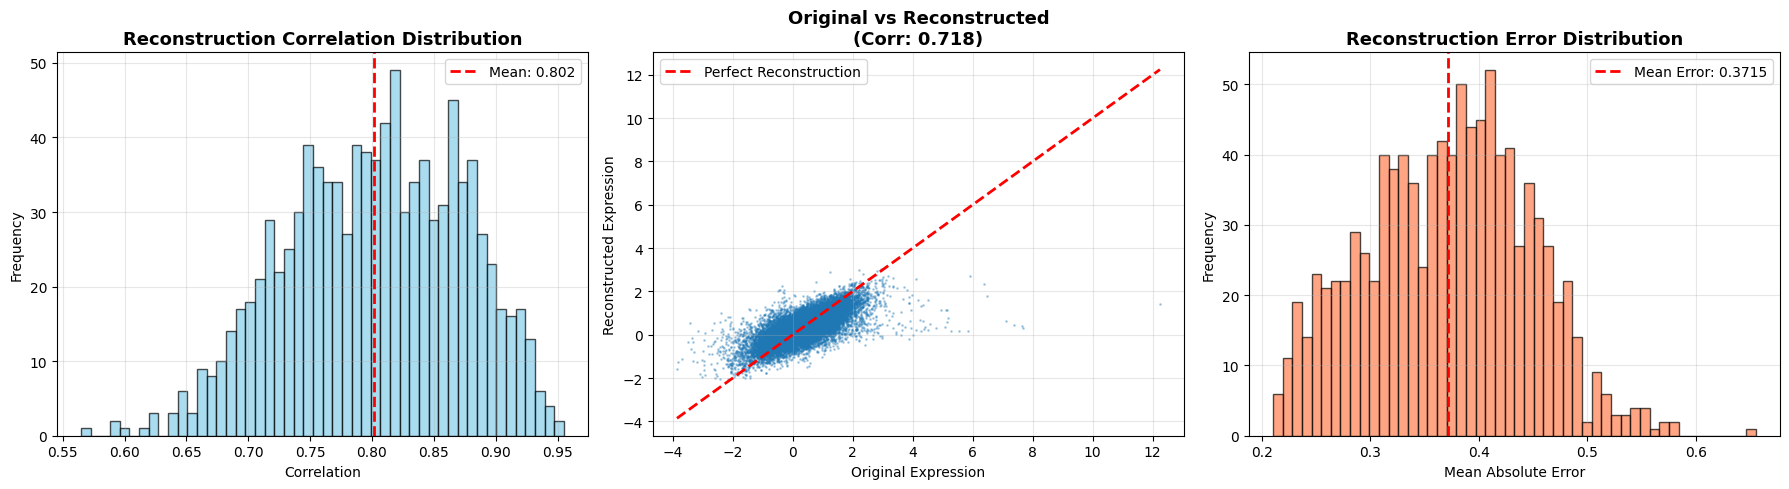


💾 Evaluation plot saved!


In [8]:
# Since we don't have training history, let's evaluate the model quality directly

if autoencoder is not None:
    print("🔹 Evaluating model performance...\n")

    # Load the data
    print("📂 Loading data...")
    tcga_df = pd.read_csv(DATA_PATH, index_col=0)
    X_data = tcga_df.values.astype('float32')

    # Load and apply scaler
    scaler_path = MODEL_DIR / "scaler.joblib"
    if scaler_path.exists():
        scaler = joblib.load(scaler_path)
        X_scaled = scaler.transform(X_data)
        print("✅ Data loaded and scaled")
    else:
        print("⚠️ Scaler not found, creating new one")
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X_data)

    del tcga_df
    gc.collect()

    # Evaluate on a sample
    print("\n🔍 Testing reconstruction quality...")
    sample_size = min(1000, len(X_scaled))
    X_test = X_scaled[:sample_size]

    # Get loss
    loss, mae = autoencoder.evaluate(X_test, X_test, batch_size=64, verbose=0)

    print(f"\n📊 Model Performance:")
    print(f"   Reconstruction Loss (MSE): {loss:.6f}")
    print(f"   Mean Absolute Error: {mae:.6f}")

    # Calculate correlations
    print("\n🔹 Calculating reconstruction correlations...")
    reconstructions = autoencoder.predict(X_test, batch_size=64, verbose=0)

    correlations = []
    for i in range(len(X_test)):
        corr = np.corrcoef(X_test[i], reconstructions[i])[0, 1]
        correlations.append(corr)

    correlations = np.array(correlations)

    print(f"\n✨ Reconstruction Quality:")
    print(f"   Mean Correlation: {correlations.mean():.4f}")
    print(f"   Median Correlation: {np.median(correlations):.4f}")
    print(f"   Min Correlation: {correlations.min():.4f}")
    print(f"   Max Correlation: {correlations.max():.4f}")

    if correlations.mean() > 0.85:
        print("\n✅ EXCELLENT! Model has high reconstruction quality!")
    elif correlations.mean() > 0.75:
        print("\n✅ GOOD! Model has acceptable reconstruction quality!")
    else:
        print("\n⚠️ Model quality could be improved")

    # Plot reconstruction quality
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Correlation distribution
    axes[0].hist(correlations, bins=50, edgecolor='black', alpha=0.7, color='skyblue')
    axes[0].axvline(correlations.mean(), color='red', linestyle='--', linewidth=2,
                    label=f'Mean: {correlations.mean():.3f}')
    axes[0].set_title('Reconstruction Correlation Distribution', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Correlation')
    axes[0].set_ylabel('Frequency')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Sample comparison
    sample_idx = 0
    axes[1].scatter(X_test[sample_idx], reconstructions[sample_idx], alpha=0.3, s=1)
    axes[1].plot([X_test[sample_idx].min(), X_test[sample_idx].max()],
                 [X_test[sample_idx].min(), X_test[sample_idx].max()],
                 'r--', linewidth=2, label='Perfect Reconstruction')
    axes[1].set_title(f'Original vs Reconstructed\n(Corr: {correlations[sample_idx]:.3f})',
                      fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Original Expression')
    axes[1].set_ylabel('Reconstructed Expression')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    # Error distribution
    errors = np.abs(X_test - reconstructions).mean(axis=1)
    axes[2].hist(errors, bins=50, edgecolor='black', alpha=0.7, color='coral')
    axes[2].axvline(errors.mean(), color='red', linestyle='--', linewidth=2,
                    label=f'Mean Error: {errors.mean():.4f}')
    axes[2].set_title('Reconstruction Error Distribution', fontsize=13, fontweight='bold')
    axes[2].set_xlabel('Mean Absolute Error')
    axes[2].set_ylabel('Frequency')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(REPORTS_DIR / "model_evaluation.png", dpi=300, bbox_inches='tight')
    plt.show()

    print("\n💾 Evaluation plot saved!")

else:
    print("⚠️ Cannot evaluate - no model loaded")

🔹 Analyzing latent space...

Extracting features from 5000 samples...
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step

🔍 Latent Space Statistics:
   Shape: (5000, 64)
   Mean: 2.7773
   Std: inf
   Min: 0.0000
   Max: 99.0000
   Sparsity (% near zero): 31.50%


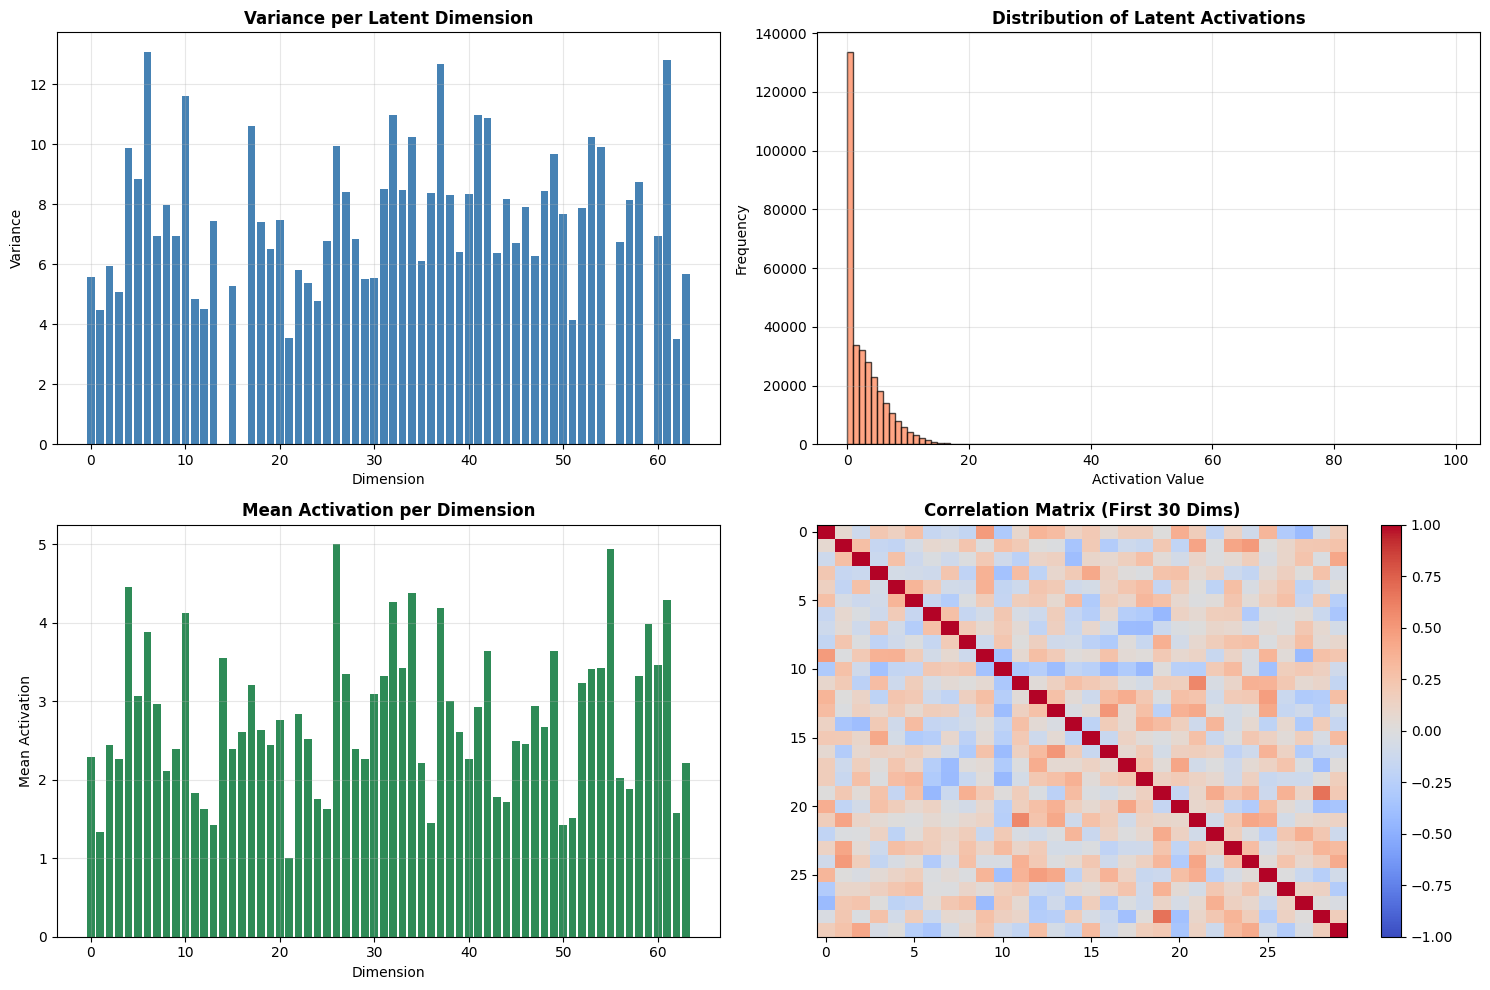


💾 Latent space analysis saved!

📊 Latent Space Summary:
   Encoding dimension: 64
   Top 5 variance dimensions: [14, 55, 59, 16, 6]
   Compression ratio: 20034/64 = 313.0x


In [9]:
# Analyze the learned latent representations

if encoder is not None and 'X_scaled' in locals():
    print("🔹 Analyzing latent space...\n")

    # Extract latent features
    n_samples = min(5000, len(X_scaled))
    sample_data = X_scaled[:n_samples]

    print(f"Extracting features from {n_samples} samples...")
    latent_reps = encoder.predict(sample_data, batch_size=128, verbose=1)

    print(f"\n🔍 Latent Space Statistics:")
    print(f"   Shape: {latent_reps.shape}")
    print(f"   Mean: {latent_reps.mean():.4f}")
    print(f"   Std: {latent_reps.std():.4f}")
    print(f"   Min: {latent_reps.min():.4f}")
    print(f"   Max: {latent_reps.max():.4f}")
    print(f"   Sparsity (% near zero): {(np.abs(latent_reps) < 0.01).mean():.2%}")

    # Visualization
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    # Variance per dimension
    variances = latent_reps.var(axis=0)
    axes[0, 0].bar(range(len(variances)), variances, color='steelblue')
    axes[0, 0].set_title('Variance per Latent Dimension', fontsize=12, fontweight='bold')
    axes[0, 0].set_xlabel('Dimension')
    axes[0, 0].set_ylabel('Variance')
    axes[0, 0].grid(True, alpha=0.3)

    # Distribution of activations
    axes[0, 1].hist(latent_reps.flatten(), bins=100, alpha=0.7, edgecolor='black', color='coral')
    axes[0, 1].set_title('Distribution of Latent Activations', fontsize=12, fontweight='bold')
    axes[0, 1].set_xlabel('Activation Value')
    axes[0, 1].set_ylabel('Frequency')
    axes[0, 1].grid(True, alpha=0.3)

    # Mean activation per dimension
    means = latent_reps.mean(axis=0)
    axes[1, 0].bar(range(len(means)), means, color='seagreen')
    axes[1, 0].set_title('Mean Activation per Dimension', fontsize=12, fontweight='bold')
    axes[1, 0].set_xlabel('Dimension')
    axes[1, 0].set_ylabel('Mean Activation')
    axes[1, 0].grid(True, alpha=0.3)

    # Correlation matrix (first 30 dimensions)
    dims_to_show = min(30, latent_reps.shape[1])
    corr = np.corrcoef(latent_reps[:, :dims_to_show].T)
    im = axes[1, 1].imshow(corr, cmap='coolwarm', vmin=-1, vmax=1, aspect='auto')
    axes[1, 1].set_title(f'Correlation Matrix (First {dims_to_show} Dims)',
                         fontsize=12, fontweight='bold')
    plt.colorbar(im, ax=axes[1, 1])

    plt.tight_layout()
    plt.savefig(REPORTS_DIR / "latent_space_analysis.png", dpi=300, bbox_inches='tight')
    plt.show()

    print("\n💾 Latent space analysis saved!")

    # Summary
    print(f"\n📊 Latent Space Summary:")
    print(f"   Encoding dimension: {latent_reps.shape[1]}")
    print(f"   Top 5 variance dimensions: {np.argsort(variances)[-5:][::-1].tolist()}")
    print(f"   Compression ratio: {X_scaled.shape[1]}/{latent_reps.shape[1]} = {X_scaled.shape[1]/latent_reps.shape[1]:.1f}x")

else:
    print("⚠️ Cannot analyze - encoder not loaded or data not available")

🔹 Comprehensive Model Evaluation...

📊 Using 1,053 samples for evaluation

🔹 Generating reconstructions...
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 112ms/step

🔹 Calculating comprehensive metrics...

📊 COMPREHENSIVE MODEL PERFORMANCE METRICS

🎯 Loss Metrics:
   MSE (Mean Squared Error):        0.291736
   MAE (Mean Absolute Error):       0.371744
   RMSE (Root Mean Squared Error):  0.532103

📈 Correlation Metrics:
   Mean Correlation:                0.8017
   Median Correlation:              0.8057
   Min Correlation:                 0.5649
   Max Correlation:                 0.9552
   Std Correlation:                 0.0708

🎓 R² Metrics:
   Mean R²:                         0.6456
   Median R²:                       0.6476

📊 Error Statistics:
   MAPE (Mean Abs Percentage Error): 2899.16%
   Max Error:                       36.278946
   99th Percentile Error:           0.547926

✨ Quality Assessment:
   ✅ GOOD reconstruction quality!


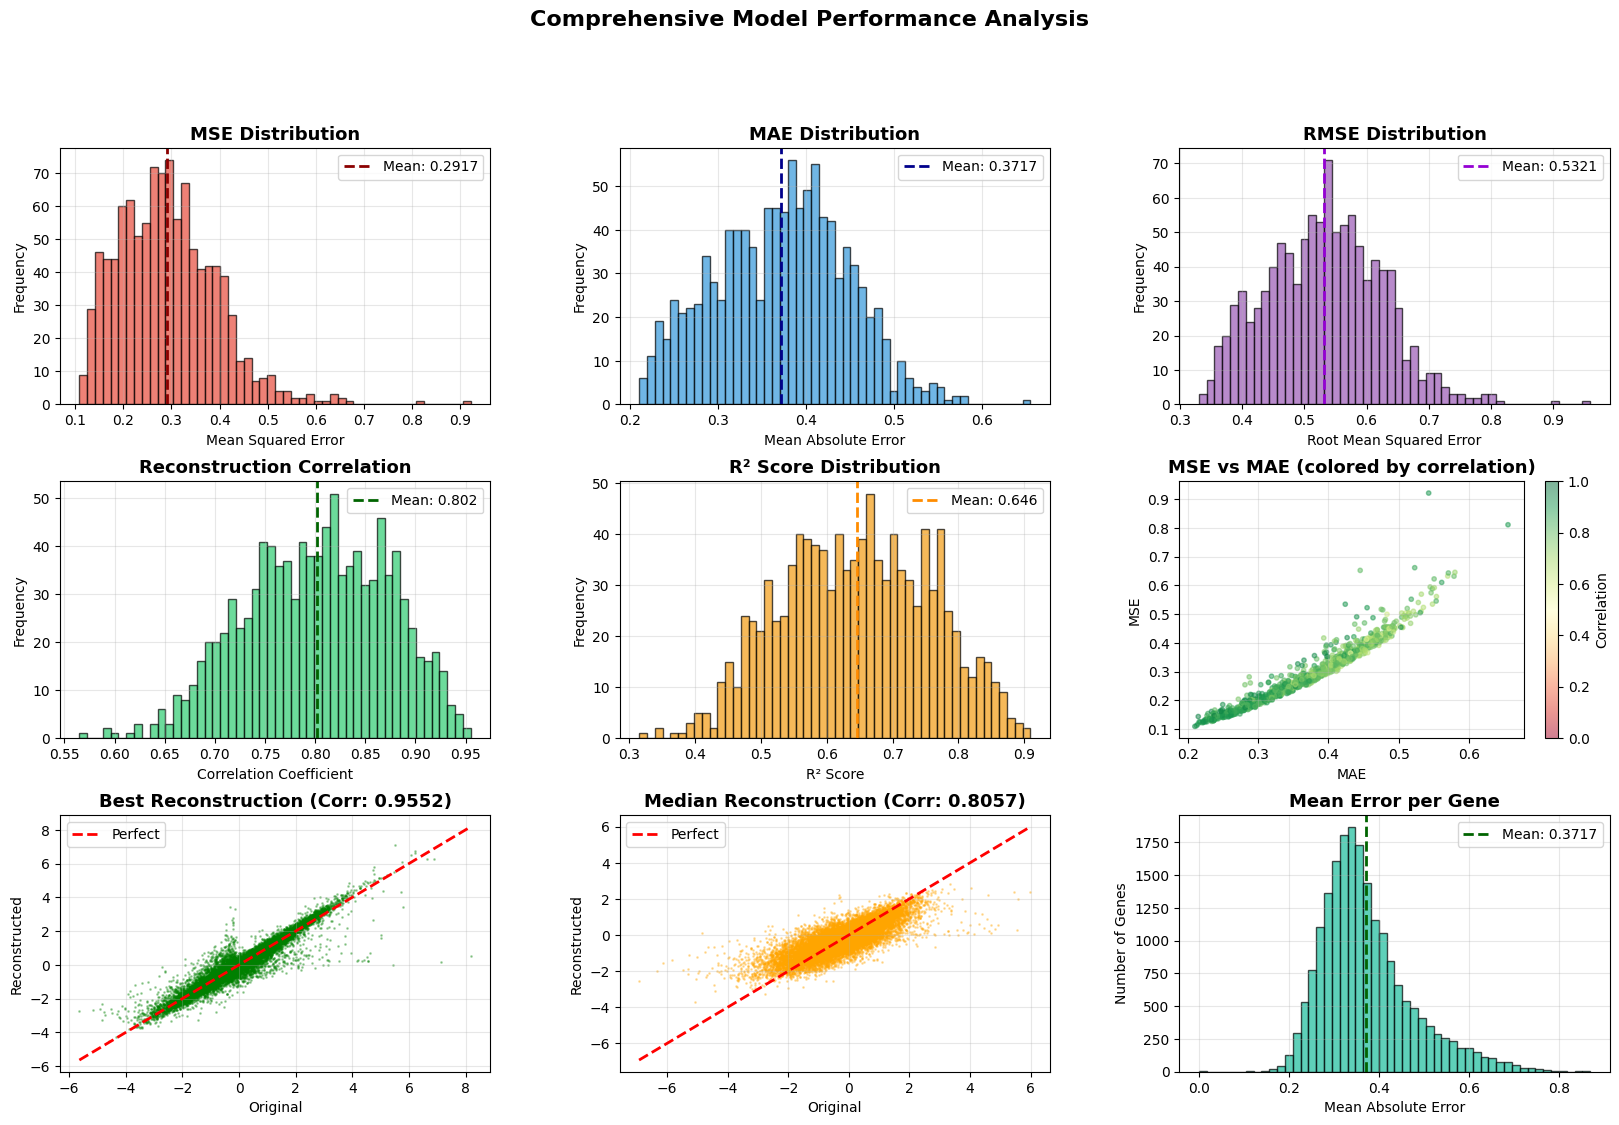


💾 Comprehensive evaluation saved!
📄 Metrics summary saved to: /content/drive/MyDrive/models/evaluation_metrics.csv


In [10]:
# Comprehensive evaluation with MAE, MSE, and detailed error analysis

if autoencoder is not None:
    print("🔹 Comprehensive Model Evaluation...\n")

    # Load the data if not already loaded
    if 'X_scaled' not in locals():
        print("📂 Loading data...")
        tcga_df = pd.read_csv(DATA_PATH, index_col=0)
        X_data = tcga_df.values.astype('float32')

        # Load and apply scaler
        scaler_path = MODEL_DIR / "scaler.joblib"
        if scaler_path.exists():
            scaler = joblib.load(scaler_path)
            X_scaled = scaler.transform(X_data)
            print("✅ Data loaded and scaled")
        else:
            print("⚠️ Scaler not found, creating new one")
            scaler = StandardScaler()
            X_scaled = scaler.fit_transform(X_data)

        del tcga_df
        gc.collect()

    # Split data for evaluation
    n_total = len(X_scaled)
    n_test = int(0.1 * n_total)  # Use 10% for testing

    X_test = X_scaled[:n_test]
    print(f"📊 Using {n_test:,} samples for evaluation")

    # Get predictions
    print("\n🔹 Generating reconstructions...")
    reconstructions = autoencoder.predict(X_test, batch_size=64, verbose=1)

    # Calculate all metrics
    print("\n🔹 Calculating comprehensive metrics...")

    # 1. MSE (Mean Squared Error)
    mse_per_sample = ((X_test - reconstructions) ** 2).mean(axis=1)
    mse_overall = mse_per_sample.mean()

    # 2. MAE (Mean Absolute Error)
    mae_per_sample = np.abs(X_test - reconstructions).mean(axis=1)
    mae_overall = mae_per_sample.mean()

    # 3. RMSE (Root Mean Squared Error)
    rmse_per_sample = np.sqrt(mse_per_sample)
    rmse_overall = rmse_per_sample.mean()

    # 4. Correlations
    correlations = []
    for i in range(len(X_test)):
        corr = np.corrcoef(X_test[i], reconstructions[i])[0, 1]
        correlations.append(corr)
    correlations = np.array(correlations)

    # 5. R-squared per sample
    r2_scores = []
    for i in range(len(X_test)):
        ss_res = np.sum((X_test[i] - reconstructions[i]) ** 2)
        ss_tot = np.sum((X_test[i] - X_test[i].mean()) ** 2)
        r2 = 1 - (ss_res / ss_tot) if ss_tot > 0 else 0
        r2_scores.append(r2)
    r2_scores = np.array(r2_scores)

    # 6. Percentage error
    # Avoid division by zero
    with np.errstate(divide='ignore', invalid='ignore'):
        mape_per_sample = np.abs((X_test - reconstructions) / (X_test + 1e-8)).mean(axis=1) * 100
        mape_per_sample = np.nan_to_num(mape_per_sample, nan=0.0, posinf=0.0, neginf=0.0)

    # Print comprehensive summary
    print("\n" + "="*70)
    print("📊 COMPREHENSIVE MODEL PERFORMANCE METRICS")
    print("="*70)

    print("\n🎯 Loss Metrics:")
    print(f"   MSE (Mean Squared Error):        {mse_overall:.6f}")
    print(f"   MAE (Mean Absolute Error):       {mae_overall:.6f}")
    print(f"   RMSE (Root Mean Squared Error):  {rmse_overall:.6f}")

    print("\n📈 Correlation Metrics:")
    print(f"   Mean Correlation:                {correlations.mean():.4f}")
    print(f"   Median Correlation:              {np.median(correlations):.4f}")
    print(f"   Min Correlation:                 {correlations.min():.4f}")
    print(f"   Max Correlation:                 {correlations.max():.4f}")
    print(f"   Std Correlation:                 {correlations.std():.4f}")

    print("\n🎓 R² Metrics:")
    print(f"   Mean R²:                         {r2_scores.mean():.4f}")
    print(f"   Median R²:                       {np.median(r2_scores):.4f}")

    print("\n📊 Error Statistics:")
    print(f"   MAPE (Mean Abs Percentage Error): {mape_per_sample.mean():.2f}%")
    print(f"   Max Error:                       {np.abs(X_test - reconstructions).max():.6f}")
    print(f"   99th Percentile Error:           {np.percentile(mae_per_sample, 99):.6f}")

    print("\n✨ Quality Assessment:")
    if correlations.mean() > 0.90:
        print("   🌟 OUTSTANDING reconstruction quality!")
    elif correlations.mean() > 0.85:
        print("   ✅ EXCELLENT reconstruction quality!")
    elif correlations.mean() > 0.75:
        print("   ✅ GOOD reconstruction quality!")
    elif correlations.mean() > 0.65:
        print("   ⚠️  FAIR reconstruction quality")
    else:
        print("   ❌ POOR reconstruction quality - consider retraining")

    print("="*70)

    # Create comprehensive visualization
    fig = plt.figure(figsize=(20, 12))
    gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

    # 1. MSE Distribution
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.hist(mse_per_sample, bins=50, edgecolor='black', alpha=0.7, color='#e74c3c')
    ax1.axvline(mse_overall, color='darkred', linestyle='--', linewidth=2,
                label=f'Mean: {mse_overall:.4f}')
    ax1.set_title('MSE Distribution', fontsize=13, fontweight='bold')
    ax1.set_xlabel('Mean Squared Error')
    ax1.set_ylabel('Frequency')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # 2. MAE Distribution
    ax2 = fig.add_subplot(gs[0, 1])
    ax2.hist(mae_per_sample, bins=50, edgecolor='black', alpha=0.7, color='#3498db')
    ax2.axvline(mae_overall, color='darkblue', linestyle='--', linewidth=2,
                label=f'Mean: {mae_overall:.4f}')
    ax2.set_title('MAE Distribution', fontsize=13, fontweight='bold')
    ax2.set_xlabel('Mean Absolute Error')
    ax2.set_ylabel('Frequency')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    # 3. RMSE Distribution
    ax3 = fig.add_subplot(gs[0, 2])
    ax3.hist(rmse_per_sample, bins=50, edgecolor='black', alpha=0.7, color='#9b59b6')
    ax3.axvline(rmse_overall, color='darkviolet', linestyle='--', linewidth=2,
                label=f'Mean: {rmse_overall:.4f}')
    ax3.set_title('RMSE Distribution', fontsize=13, fontweight='bold')
    ax3.set_xlabel('Root Mean Squared Error')
    ax3.set_ylabel('Frequency')
    ax3.legend()
    ax3.grid(True, alpha=0.3)

    # 4. Correlation Distribution
    ax4 = fig.add_subplot(gs[1, 0])
    ax4.hist(correlations, bins=50, edgecolor='black', alpha=0.7, color='#2ecc71')
    ax4.axvline(correlations.mean(), color='darkgreen', linestyle='--', linewidth=2,
                label=f'Mean: {correlations.mean():.3f}')
    ax4.set_title('Reconstruction Correlation', fontsize=13, fontweight='bold')
    ax4.set_xlabel('Correlation Coefficient')
    ax4.set_ylabel('Frequency')
    ax4.legend()
    ax4.grid(True, alpha=0.3)

    # 5. R² Distribution
    ax5 = fig.add_subplot(gs[1, 1])
    ax5.hist(r2_scores, bins=50, edgecolor='black', alpha=0.7, color='#f39c12')
    ax5.axvline(r2_scores.mean(), color='darkorange', linestyle='--', linewidth=2,
                label=f'Mean: {r2_scores.mean():.3f}')
    ax5.set_title('R² Score Distribution', fontsize=13, fontweight='bold')
    ax5.set_xlabel('R² Score')
    ax5.set_ylabel('Frequency')
    ax5.legend()
    ax5.grid(True, alpha=0.3)

    # 6. MSE vs MAE Scatter
    ax6 = fig.add_subplot(gs[1, 2])
    scatter = ax6.scatter(mae_per_sample, mse_per_sample, alpha=0.5, s=10, c=correlations,
                         cmap='RdYlGn', vmin=0, vmax=1)
    ax6.set_title('MSE vs MAE (colored by correlation)', fontsize=13, fontweight='bold')
    ax6.set_xlabel('MAE')
    ax6.set_ylabel('MSE')
    plt.colorbar(scatter, ax=ax6, label='Correlation')
    ax6.grid(True, alpha=0.3)

    # 7. Original vs Reconstructed (Best sample)
    ax7 = fig.add_subplot(gs[2, 0])
    best_idx = np.argmax(correlations)
    ax7.scatter(X_test[best_idx], reconstructions[best_idx], alpha=0.3, s=1, color='green')
    ax7.plot([X_test[best_idx].min(), X_test[best_idx].max()],
             [X_test[best_idx].min(), X_test[best_idx].max()],
             'r--', linewidth=2, label='Perfect')
    ax7.set_title(f'Best Reconstruction (Corr: {correlations[best_idx]:.4f})',
                  fontsize=13, fontweight='bold')
    ax7.set_xlabel('Original')
    ax7.set_ylabel('Reconstructed')
    ax7.legend()
    ax7.grid(True, alpha=0.3)

    # 8. Original vs Reconstructed (Median sample)
    ax8 = fig.add_subplot(gs[2, 1])
    median_idx = np.argsort(correlations)[len(correlations)//2]
    ax8.scatter(X_test[median_idx], reconstructions[median_idx], alpha=0.3, s=1, color='orange')
    ax8.plot([X_test[median_idx].min(), X_test[median_idx].max()],
             [X_test[median_idx].min(), X_test[median_idx].max()],
             'r--', linewidth=2, label='Perfect')
    ax8.set_title(f'Median Reconstruction (Corr: {correlations[median_idx]:.4f})',
                  fontsize=13, fontweight='bold')
    ax8.set_xlabel('Original')
    ax8.set_ylabel('Reconstructed')
    ax8.legend()
    ax8.grid(True, alpha=0.3)

    # 9. Error per Gene (mean across samples)
    ax9 = fig.add_subplot(gs[2, 2])
    error_per_gene = np.abs(X_test - reconstructions).mean(axis=0)
    ax9.hist(error_per_gene, bins=50, edgecolor='black', alpha=0.7, color='#1abc9c')
    ax9.axvline(error_per_gene.mean(), color='darkgreen', linestyle='--', linewidth=2,
                label=f'Mean: {error_per_gene.mean():.4f}')
    ax9.set_title('Mean Error per Gene', fontsize=13, fontweight='bold')
    ax9.set_xlabel('Mean Absolute Error')
    ax9.set_ylabel('Number of Genes')
    ax9.legend()
    ax9.grid(True, alpha=0.3)

    plt.suptitle('Comprehensive Model Performance Analysis',
                 fontsize=16, fontweight='bold', y=0.995)

    plt.savefig(REPORTS_DIR / "comprehensive_evaluation.png", dpi=300, bbox_inches='tight')
    plt.show()

    print("\n💾 Comprehensive evaluation saved!")

    # Additional: Create a summary metrics table
    metrics_summary = pd.DataFrame({
        'Metric': [
            'MSE', 'MAE', 'RMSE',
            'Mean Correlation', 'Median Correlation', 'Min Correlation', 'Max Correlation',
            'Mean R²', 'Median R²',
            'MAPE (%)'
        ],
        'Value': [
            f"{mse_overall:.6f}",
            f"{mae_overall:.6f}",
            f"{rmse_overall:.6f}",
            f"{correlations.mean():.4f}",
            f"{np.median(correlations):.4f}",
            f"{correlations.min():.4f}",
            f"{correlations.max():.4f}",
            f"{r2_scores.mean():.4f}",
            f"{np.median(r2_scores):.4f}",
            f"{mape_per_sample.mean():.2f}"
        ]
    })

    # Save metrics to CSV
    metrics_summary.to_csv(MODEL_DIR / "evaluation_metrics.csv", index=False)
    print(f"📄 Metrics summary saved to: {MODEL_DIR / 'evaluation_metrics.csv'}")

    # Store metrics for later use
    evaluation_results = {
        'mse': mse_per_sample,
        'mae': mae_per_sample,
        'rmse': rmse_per_sample,
        'correlations': correlations,
        'r2_scores': r2_scores,
        'mape': mape_per_sample
    }

else:
    print("⚠️ Cannot evaluate - no model loaded")

🔹 Analyzing error patterns across expression ranges...



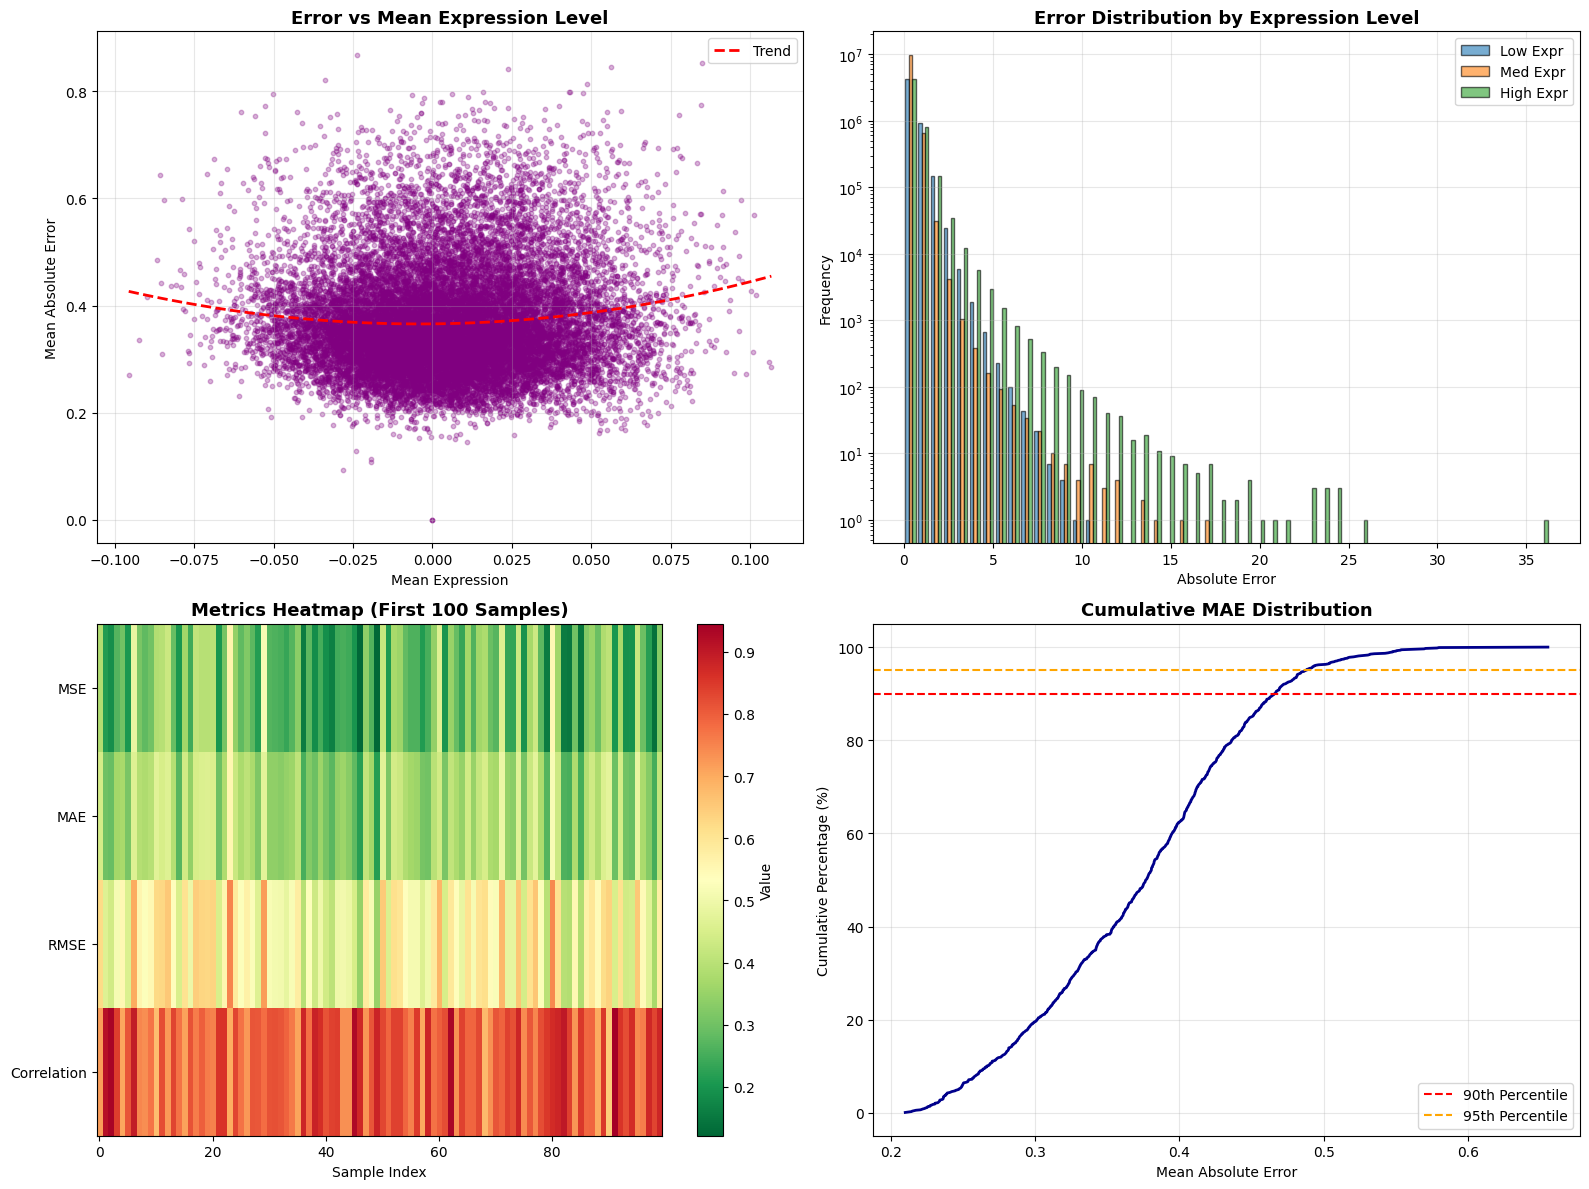

💾 Detailed error analysis saved!

📊 Error by Expression Level:
   Low expression error:  0.468700
   Med expression error:  0.283482
   High expression error: 0.451316


In [11]:
# Additional analysis: How does error vary with expression level?

if autoencoder is not None and 'X_test' in locals():
    print("🔹 Analyzing error patterns across expression ranges...\n")

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # 1. Error vs Expression Level
    mean_expression = X_test.mean(axis=0)
    mean_error = np.abs(X_test - reconstructions).mean(axis=0)

    axes[0, 0].scatter(mean_expression, mean_error, alpha=0.3, s=10, color='purple')
    axes[0, 0].set_title('Error vs Mean Expression Level', fontsize=13, fontweight='bold')
    axes[0, 0].set_xlabel('Mean Expression')
    axes[0, 0].set_ylabel('Mean Absolute Error')
    axes[0, 0].grid(True, alpha=0.3)

    # Add trend line
    z = np.polyfit(mean_expression, mean_error, 2)
    p = np.poly1d(z)
    x_line = np.linspace(mean_expression.min(), mean_expression.max(), 100)
    axes[0, 0].plot(x_line, p(x_line), "r--", linewidth=2, label='Trend')
    axes[0, 0].legend()

    # 2. Error Distribution by Expression Quartiles
    quartiles = np.percentile(X_test.flatten(), [25, 50, 75])

    low_expr = X_test[X_test < quartiles[0]]
    med_expr = X_test[(X_test >= quartiles[0]) & (X_test < quartiles[2])]
    high_expr = X_test[X_test >= quartiles[2]]

    low_recon = reconstructions[X_test < quartiles[0]]
    med_recon = reconstructions[(X_test >= quartiles[0]) & (X_test < quartiles[2])]
    high_recon = reconstructions[X_test >= quartiles[2]]

    error_low = np.abs(low_expr - low_recon)
    error_med = np.abs(med_expr - med_recon)
    error_high = np.abs(high_expr - high_recon)

    axes[0, 1].hist([error_low, error_med, error_high], bins=50,
                    label=['Low Expr', 'Med Expr', 'High Expr'],
                    alpha=0.6, edgecolor='black')
    axes[0, 1].set_title('Error Distribution by Expression Level', fontsize=13, fontweight='bold')
    axes[0, 1].set_xlabel('Absolute Error')
    axes[0, 1].set_ylabel('Frequency')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    axes[0, 1].set_yscale('log')

    # 3. Heatmap: Sample vs Error Metrics
    sample_metrics = np.column_stack([
        mse_per_sample[:100],  # First 100 samples
        mae_per_sample[:100],
        rmse_per_sample[:100],
        correlations[:100]
    ])

    im = axes[1, 0].imshow(sample_metrics.T, aspect='auto', cmap='RdYlGn_r',
                           interpolation='nearest')
    axes[1, 0].set_title('Metrics Heatmap (First 100 Samples)', fontsize=13, fontweight='bold')
    axes[1, 0].set_xlabel('Sample Index')
    axes[1, 0].set_yticks([0, 1, 2, 3])
    axes[1, 0].set_yticklabels(['MSE', 'MAE', 'RMSE', 'Correlation'])
    plt.colorbar(im, ax=axes[1, 0], label='Value')

    # 4. Cumulative Error Distribution
    sorted_mae = np.sort(mae_per_sample)
    cumulative = np.arange(1, len(sorted_mae) + 1) / len(sorted_mae) * 100

    axes[1, 1].plot(sorted_mae, cumulative, linewidth=2, color='darkblue')
    axes[1, 1].axhline(y=90, color='r', linestyle='--', label='90th Percentile')
    axes[1, 1].axhline(y=95, color='orange', linestyle='--', label='95th Percentile')
    axes[1, 1].set_title('Cumulative MAE Distribution', fontsize=13, fontweight='bold')
    axes[1, 1].set_xlabel('Mean Absolute Error')
    axes[1, 1].set_ylabel('Cumulative Percentage (%)')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(REPORTS_DIR / "error_analysis_detailed.png", dpi=300, bbox_inches='tight')
    plt.show()

    print("💾 Detailed error analysis saved!")

    # Print statistics
    print(f"\n📊 Error by Expression Level:")
    print(f"   Low expression error:  {error_low.mean():.6f}")
    print(f"   Med expression error:  {error_med.mean():.6f}")
    print(f"   High expression error: {error_high.mean():.6f}")

else:
    print("⚠️ Cannot analyze - no evaluation data available")

In [12]:
# Create a beautiful summary table

if 'evaluation_results' in locals():
    print("\n" + "="*70)
    print("📊 FINAL EVALUATION SUMMARY TABLE")
    print("="*70)

    summary_data = {
        'Metric Category': [
            'Loss Metrics', '', '', '',
            'Correlation Metrics', '', '', '',
            'R² Metrics', '',
            'Percentile Analysis', '', ''
        ],
        'Metric Name': [
            'MSE', 'MAE', 'RMSE', 'MAPE',
            'Mean Correlation', 'Median Correlation', 'Std Correlation', 'Min Correlation',
            'Mean R²', 'Median R²',
            '50th Percentile (MAE)', '90th Percentile (MAE)', '95th Percentile (MAE)'
        ],
        'Value': [
            f"{mse_overall:.6f}",
            f"{mae_overall:.6f}",
            f"{rmse_overall:.6f}",
            f"{mape_per_sample.mean():.2f}%",
            f"{correlations.mean():.4f}",
            f"{np.median(correlations):.4f}",
            f"{correlations.std():.4f}",
            f"{correlations.min():.4f}",
            f"{r2_scores.mean():.4f}",
            f"{np.median(r2_scores):.4f}",
            f"{np.percentile(mae_per_sample, 50):.6f}",
            f"{np.percentile(mae_per_sample, 90):.6f}",
            f"{np.percentile(mae_per_sample, 95):.6f}"
        ]
    }

    summary_df = pd.DataFrame(summary_data)
    print(summary_df.to_string(index=False))
    print("="*70)

    print("\n💾 Saving complete evaluation report...")
    summary_df.to_csv(MODEL_DIR / "complete_evaluation_summary.csv", index=False)
    print(f"✅ Saved to: {MODEL_DIR / 'complete_evaluation_summary.csv'}")

else:
    print("⚠️ Run evaluation first")


📊 FINAL EVALUATION SUMMARY TABLE
    Metric Category           Metric Name    Value
       Loss Metrics                   MSE 0.291736
                                      MAE 0.371744
                                     RMSE 0.532103
                                     MAPE 2899.16%
Correlation Metrics      Mean Correlation   0.8017
                       Median Correlation   0.8057
                          Std Correlation   0.0708
                          Min Correlation   0.5649
         R² Metrics               Mean R²   0.6456
                                Median R²   0.6476
Percentile Analysis 50th Percentile (MAE) 0.376973
                    90th Percentile (MAE) 0.466228
                    95th Percentile (MAE) 0.487518

💾 Saving complete evaluation report...
✅ Saved to: /content/drive/MyDrive/models/complete_evaluation_summary.csv


In [13]:
def extract_leukemia_features():
    """Extract latent features from leukemia data using trained encoder"""

    print("🔹 Processing leukemia data for feature extraction...")

    # Define paths for leukemia data in Google Drive
    leukemia_data_path = Path(f"{DRIVE_BASE}/leukemia_filtered.csv")
    metadata_path = Path(f"{DRIVE_BASE}/leukemia_sample_info.csv")

    # Check if files exist
    if not leukemia_data_path.exists():
        print(f"❌ Leukemia data not found at: {leukemia_data_path}")
        print("💡 Please upload 'leukemia_filtered.csv' to your Google Drive")
        print(f"💡 Expected location: {DRIVE_BASE}/leukemia_filtered.csv")
        return None

    if not metadata_path.exists():
        print(f"❌ Metadata not found at: {metadata_path}")
        print("💡 Please upload 'leukemia_sample_info.csv' to your Google Drive")
        print(f"💡 Expected location: {DRIVE_BASE}/leukemia_sample_info.csv")
        return None

    # Load leukemia data
    print("📂 Loading leukemia data...")
    leukemia_df = pd.read_csv(leukemia_data_path, index_col=0)

    # Load metadata
    print("📂 Loading metadata...")
    metadata_df = pd.read_csv(metadata_path)

    print(f"✅ Leukemia data loaded: {leukemia_df.shape}")
    print(f"✅ Metadata loaded: {metadata_df.shape}")

    # Load scaler
    scaler_path = MODEL_DIR / "scaler.joblib"
    if not scaler_path.exists():
        print("❌ Scaler not found! Cannot proceed.")
        return None

    scaler = joblib.load(scaler_path)
    print("✅ Scaler loaded")

    # Transform leukemia data
    print("🔹 Standardizing leukemia data...")
    X_leukemia = scaler.transform(leukemia_df.values.astype('float32'))

    # Load encoder
    if encoder is None:
        print("❌ Encoder not loaded! Please run the model loading cell first.")
        return None

    print("✅ Using loaded encoder")

    # Extract latent features
    print("🔹 Extracting latent features from leukemia data...")
    leukemia_latent = encoder.predict(X_leukemia, batch_size=64, verbose=1)

    print(f"✅ Latent features extracted: {leukemia_latent.shape}")

    # Create feature dataframe
    latent_cols = [f'latent_{i:02d}' for i in range(leukemia_latent.shape[1])]
    latent_df = pd.DataFrame(
        leukemia_latent,
        columns=latent_cols,
        index=leukemia_df.index
    )

    # Combine with metadata
    print("🔹 Combining features with metadata...")
    final_df = latent_df.copy()

    # Merge with metadata
    if 'sample' in metadata_df.columns:
        metadata_indexed = metadata_df.set_index('sample')
        final_df['disease'] = metadata_indexed.loc[final_df.index, 'disease']
    elif metadata_df.index.name == 'sample' or len(metadata_df) == len(final_df):
        final_df['disease'] = metadata_df['disease'].values
    else:
        print("⚠️ Warning: Could not match metadata to samples")
        final_df['disease'] = 'Unknown'

    final_df['sample_id'] = final_df.index

    # Save extracted features
    features_path = Path(f"{DRIVE_BASE}/leukemia_latent_features.csv")
    final_df.to_csv(features_path, index=True)

    print(f"\n✅ Leukemia features extracted and saved!")
    print(f"📂 Saved to: {features_path}")
    print(f"📊 Final shape: {final_df.shape}")
    print(f"💡 Features: {leukemia_latent.shape[1]} latent dimensions + disease labels")

    # Display sample of the data
    print("\n📋 Sample of extracted features:")
    print(final_df.head())

    # Display disease distribution
    print("\n📊 Disease distribution:")
    print(final_df['disease'].value_counts())

    return final_df

# Check if encoder is loaded
if 'encoder' not in locals() or encoder is None:
    print("⚠️ Encoder not found in memory. Loading encoder first...")

    # Try to load encoder
    encoder_paths = [
        MODEL_DIR / "encoder_final.keras",
        MODEL_DIR / "encoder_final.h5",
    ]

    encoder = None
    for path in encoder_paths:
        if path.exists():
            print(f"📂 Loading encoder from: {path}")
            try:
                # If we have the autoencoder, extract encoder from it
                if 'autoencoder' in locals() and autoencoder is not None:
                    encoder = keras.Model(
                        inputs=autoencoder.input,
                        outputs=autoencoder.get_layer('latent_bottleneck').output,
                        name='Encoder_For_Leukemia'
                    )
                    print("✅ Encoder extracted from autoencoder")
                else:
                    encoder = keras.models.load_model(path)
                    print("✅ Encoder loaded from file")
                break
            except Exception as e:
                print(f"❌ Failed to load: {e}")
                continue

    if encoder is None:
        print("\n❌ Could not load encoder. Please run the model loading cell first.")
        print("Required: Cell that loads the autoencoder/encoder")

# Extract features
if encoder is not None:
    print("\n" + "="*70)
    print("🚀 STARTING LEUKEMIA FEATURE EXTRACTION")
    print("="*70 + "\n")

    leukemia_features = extract_leukemia_features()

    if leukemia_features is not None:
        print("\n" + "="*70)
        print("🎉 LEUKEMIA FEATURE EXTRACTION COMPLETED!")
        print("="*70)
        print("\n✅ Ready for Phase 3: Classification Model Training")
        print("💡 Next step: Train classifier on extracted latent features")
    else:
        print("\n❌ Feature extraction failed. Check error messages above.")
else:
    print("\n❌ Cannot proceed without encoder. Load the model first!")


🚀 STARTING LEUKEMIA FEATURE EXTRACTION

🔹 Processing leukemia data for feature extraction...
📂 Loading leukemia data...
📂 Loading metadata...
✅ Leukemia data loaded: (357, 20034)
✅ Metadata loaded: (357, 2)
✅ Scaler loaded
🔹 Standardizing leukemia data...
✅ Using loaded encoder
🔹 Extracting latent features from leukemia data...
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 144ms/step
✅ Latent features extracted: (357, 64)
🔹 Combining features with metadata...

✅ Leukemia features extracted and saved!
📂 Saved to: /content/drive/MyDrive/leukemia_latent_features.csv
📊 Final shape: (357, 66)
💡 Features: 64 latent dimensions + disease labels

📋 Sample of extracted features:
           latent_00  latent_01  latent_02  latent_03  latent_04  latent_05  \
GSM329423        0.0  19.546875  30.640625   0.000000        0.0        0.0   
GSM329441        0.0  18.000000  30.593750   0.000000        0.0        0.0   
GSM329448        0.0  13.335938  26.312500   0.000000        0.0        0.0   
GSM329449        0.0  1